# EDA và thống kê cơ bản cho dữ liệu log mạng

Notebook này tập trung vào bước khám phá dữ liệu, thống kê mô tả và trực quan hóa để hiểu nhanh hành vi normal và leakage trong tập log mạng.

Mục tiêu chính:
- Kiểm tra cấu trúc dữ liệu và chất lượng dữ liệu.
- Thống kê cơ bản cho các biến số và biến phân loại.
- Vẽ các biểu đồ giúp nhận diện dấu hiệu rò rỉ dữ liệu.
- Tạo nền cho bước tiền xử lý và mô hình hóa sau này.

## 1. Khởi tạo môi trường và đọc dữ liệu

Cell này nạp các thư viện cần thiết, đọc file CSV và tạo thêm đặc trưng tỷ lệ upload/download để phục vụ phân tích.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_FILE = Path('data/network_logs.csv')
if not DATA_FILE.exists():
    raise FileNotFoundError(f'Không tìm thấy file dữ liệu: {DATA_FILE}')

df = pd.read_csv(DATA_FILE)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['upload_download_ratio'] = df['bytes_sent'] / df['bytes_recv'].replace(0, np.nan)
df['upload_download_ratio'] = df['upload_download_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0.0)

print(f'Số dòng: {len(df):,}')
print(f'Số cột: {df.shape[1]}')
display(df.head())

Số dòng: 100,000
Số cột: 12


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration,hour_of_day,is_external_dst,label,upload_download_ratio
0,2025-11-07 14:18:19,192.168.2.104,192.168.2.224,53,UDP,104.08,213.77,32.05,14,0,0,0.486878
1,2025-10-11 14:03:25,172.16.0.163,1.1.1.1.251,9001,UDP,1.22,174.23,13.87,14,1,0,0.007002
2,2025-11-12 13:14:45,10.0.1.194,172.18.0.20,110,TCP,24.40,183.40,60.32,13,0,0,0.133043
3,2025-10-01 19:17:55,192.168.1.5,192.168.2.148,11211,TCP,17681.88,52.91,1.56,19,0,0,334.187866
4,2025-11-10 04:50:08,172.18.0.165,104.16.85.34,8080,TCP,460652.75,0.92,815.77,4,1,1,500709.510870


## 2. Tổng quan dữ liệu

Kiểm tra dtype, số lượng giá trị thiếu, số bản ghi trùng và phân bố nhãn.

In [2]:
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'nunique': df.nunique()
}).sort_values('missing', ascending=False)

print('Thông tin tổng quan:')
df.info()
print()
print(f'Số bản ghi trùng: {df.duplicated().sum()}')
print()
display(overview)

label_map = {0: 'Normal', 1: 'Leakage'}
label_summary = (
    df['label']
    .value_counts()
    .rename(index=label_map)
    .to_frame(name='count')
)
label_summary['ratio_%'] = (label_summary['count'] / len(df) * 100).round(2)
display(label_summary)

Thông tin tổng quan:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   timestamp              100000 non-null  datetime64[us]
 1   src_ip                 100000 non-null  str           
 2   dst_ip                 100000 non-null  str           
 3   dst_port               100000 non-null  int64         
 4   protocol               100000 non-null  str           
 5   bytes_sent             100000 non-null  float64       
 6   bytes_recv             100000 non-null  float64       
 7   duration               100000 non-null  float64       
 8   hour_of_day            100000 non-null  int64         
 9   is_external_dst        100000 non-null  int64         
 10  label                  100000 non-null  int64         
 11  upload_download_ratio  100000 non-null  float64       
dtypes: datetime64[us](1), float64(4), i

,dtype,missing,nunique
timestamp,datetime64[us],0,98600
src_ip,str,0,2540
dst_ip,str,0,5588
dst_port,int64,0,41
protocol,str,0,3
bytes_sent,float64,0,46122
bytes_recv,float64,0,50874
duration,float64,0,33299
hour_of_day,int64,0,24
is_external_dst,int64,0,2


,count,ratio_%
label,,
Normal,88000,88.0
Leakage,12000,12.0


## 3. Thống kê mô tả cơ bản

Phần này xem phân phối của các biến số, biến phân loại và một số chỉ số nhóm theo nhãn.

In [3]:
numeric_cols = ['bytes_sent', 'bytes_recv', 'duration', 'hour_of_day', 'dst_port', 'upload_download_ratio']
categorical_cols = ['protocol', 'is_external_dst', 'label']

print('Thống kê mô tả cho biến số:')
display(df[numeric_cols].describe().T.round(2))

print('Tần suất cho các biến phân loại:')
for col in categorical_cols:
    print(f'--- {col} ---')
    display(df[col].value_counts(dropna=False).to_frame(name='count'))

print('Thống kê theo nhãn:')
grouped_stats = df.groupby('label')[numeric_cols].agg(['mean', 'median', 'min', 'max']).round(2)
display(grouped_stats)

print('Top 10 cổng đích xuất hiện nhiều nhất:')
display(df['dst_port'].value_counts().head(10).to_frame(name='count'))

print('Top 3 giao thức:')
display(df['protocol'].value_counts().to_frame(name='count'))

Thống kê mô tả cho biến số:


,count,mean,std,min,25%,50%,75%,max
bytes_sent,100000.0,41921.22,138753.18,0.0,18.50,59.69,948.94,799790.99
bytes_recv,100000.0,7780.35,30167.28,0.0,40.72,143.51,369.31,199914.11
duration,100000.0,217.26,405.61,0.0,15.60,40.40,114.72,1999.98
hour_of_day,100000.0,12.09,4.97,0.0,9.00,12.00,15.00,23.00
dst_port,100000.0,6551.38,8658.80,21.0,110.00,5432.00,8443.00,30003.00
upload_download_ratio,100000.0,20181.99,526745.73,0.0,0.10,0.44,3.83,75973237.00


Tần suất cho các biến phân loại:
--- protocol ---


,count
protocol,
TCP,67669
UDP,27922
ICMP,4409


--- is_external_dst ---


...

bytes_sent                              bytes_recv                \
            mean     median    min        max       mean  median   min   
label                                                                    
0        3184.31      45.61   0.00   79995.37    8839.25  180.66  0.01   
1      325991.90  312875.59  50.15  799790.99      15.09   10.27  0.00   

                 duration          ... hour_of_day     dst_port              \
             max     mean  median  ...         min max     mean  median min   
label                              ...                                        
0      199914.11   167.39   33.62  ...           0  23  7003.40  5672.0  21   
1         137.84   582.98  575.79  ...           0  23  3236.57   443.0  21   

             upload_download_ratio                             
         max                  mean    median  min         max  
label                                                          
0      30003                 24.52      0.33  0.0      8920.0  
1      27017             168003.38  22773.56  0.0  75973237.0  

[2 rows x 24 columns]

Top 10 cổng đích xuất hiện nhiều nhất:


,count
dst_port,
53,9650
22,5789
443,4907
8443,3678
8080,3508
8000,3467
465,3054
25,3025
587,2981


Top 3 giao thức:


,count
protocol,
TCP,67669
UDP,27922
ICMP,4409


## 4. Trực quan hóa phân bố nhãn và biến phân loại

Các biểu đồ này giúp nhìn nhanh mất cân bằng lớp, giao thức phổ biến và tỷ lệ kết nối ra ngoài.

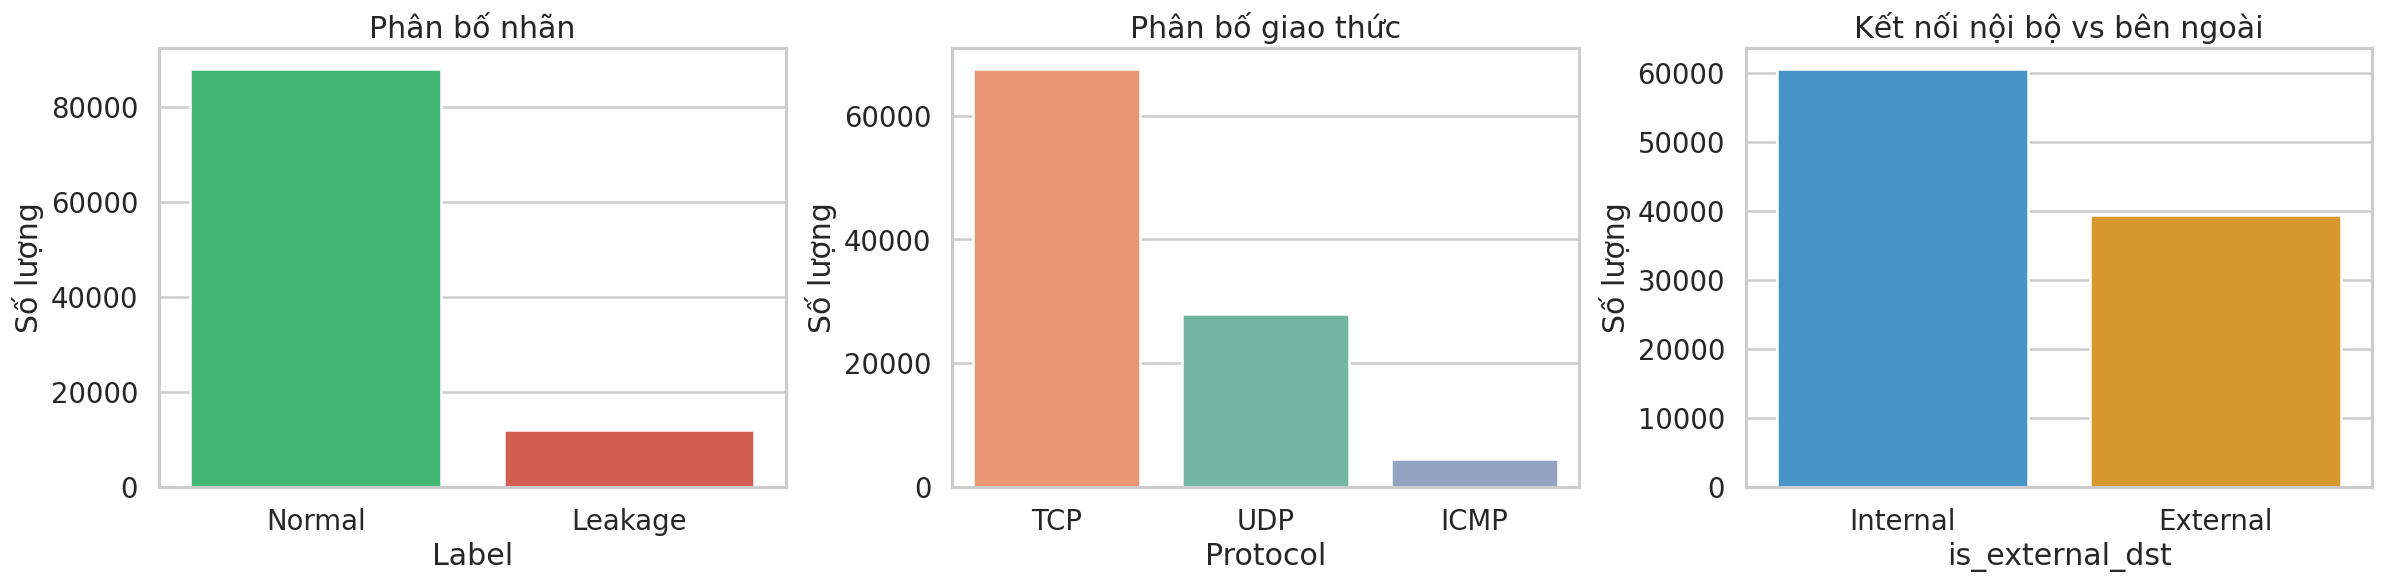

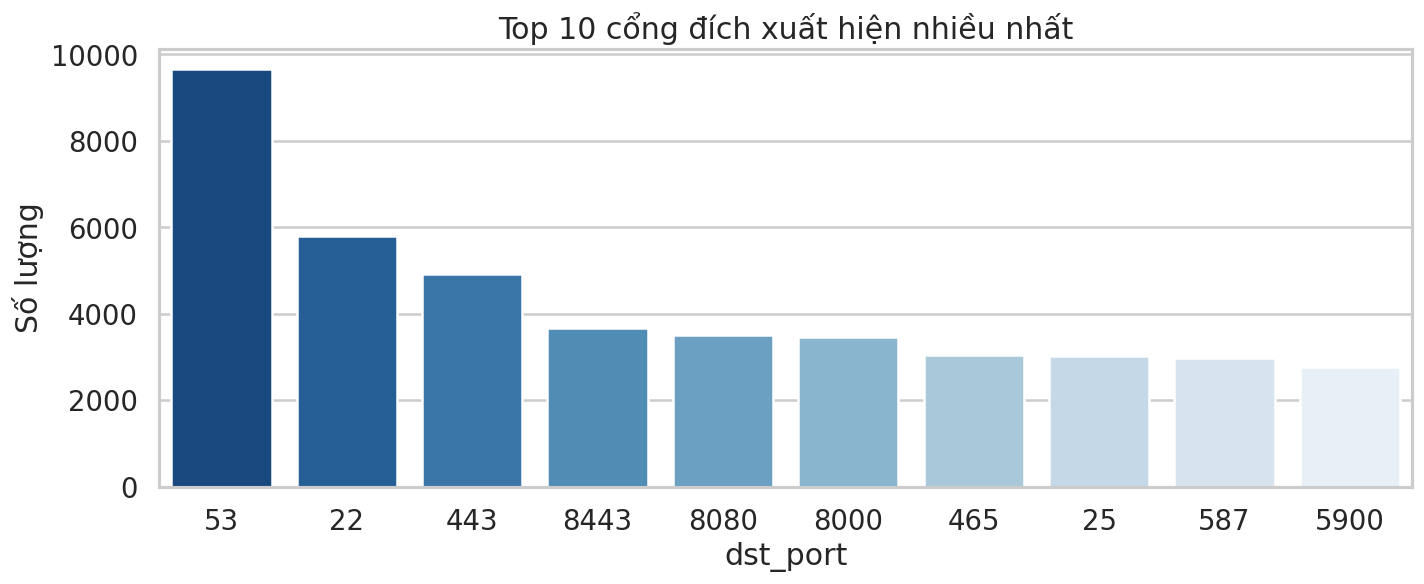

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.countplot(data=df, x='label', hue='label', palette=['#2ecc71', '#e74c3c'], ax=axes[0], legend=False)
axes[0].set_title('Phân bố nhãn')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Số lượng')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Leakage'])

sns.countplot(data=df, x='protocol', hue='protocol', order=df['protocol'].value_counts().index, palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('Phân bố giao thức')
axes[1].set_xlabel('Protocol')
axes[1].set_ylabel('Số lượng')

sns.countplot(data=df, x='is_external_dst', hue='is_external_dst', palette=['#3498db', '#f39c12'], ax=axes[2], legend=False)
axes[2].set_title('Kết nối nội bộ vs bên ngoài')
axes[2].set_xlabel('is_external_dst')
axes[2].set_ylabel('Số lượng')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Internal', 'External'])

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
top_ports = df['dst_port'].value_counts().head(10)
sns.barplot(x=top_ports.index.astype(str), y=top_ports.values, hue=top_ports.index.astype(str), palette='Blues_r', legend=False)
plt.title('Top 10 cổng đích xuất hiện nhiều nhất')
plt.xlabel('dst_port')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

## 5. Trực quan hóa biến số và dấu hiệu bất thường

Ở đây tập trung vào các cột phản ánh hành vi: bytes_sent, bytes_recv, duration và upload_download_ratio.

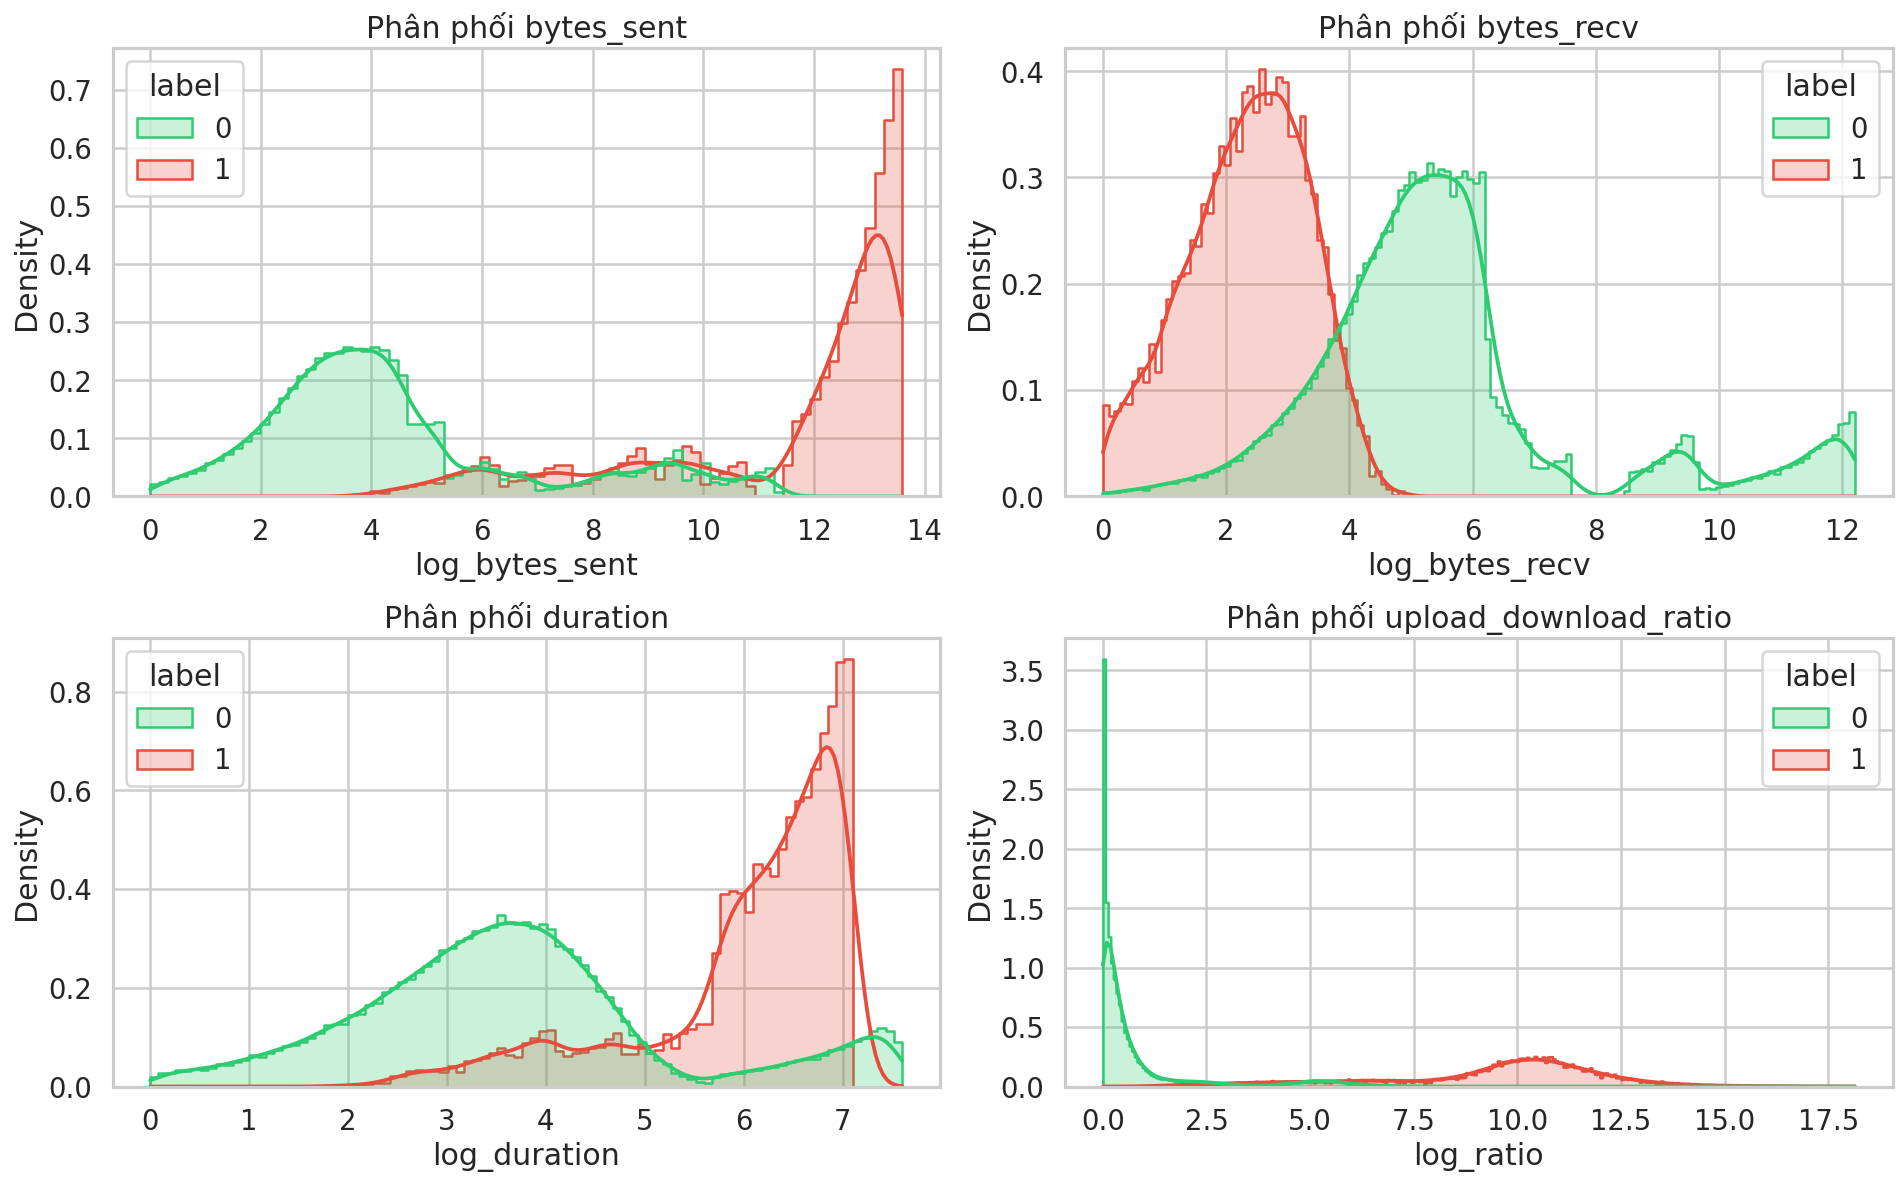

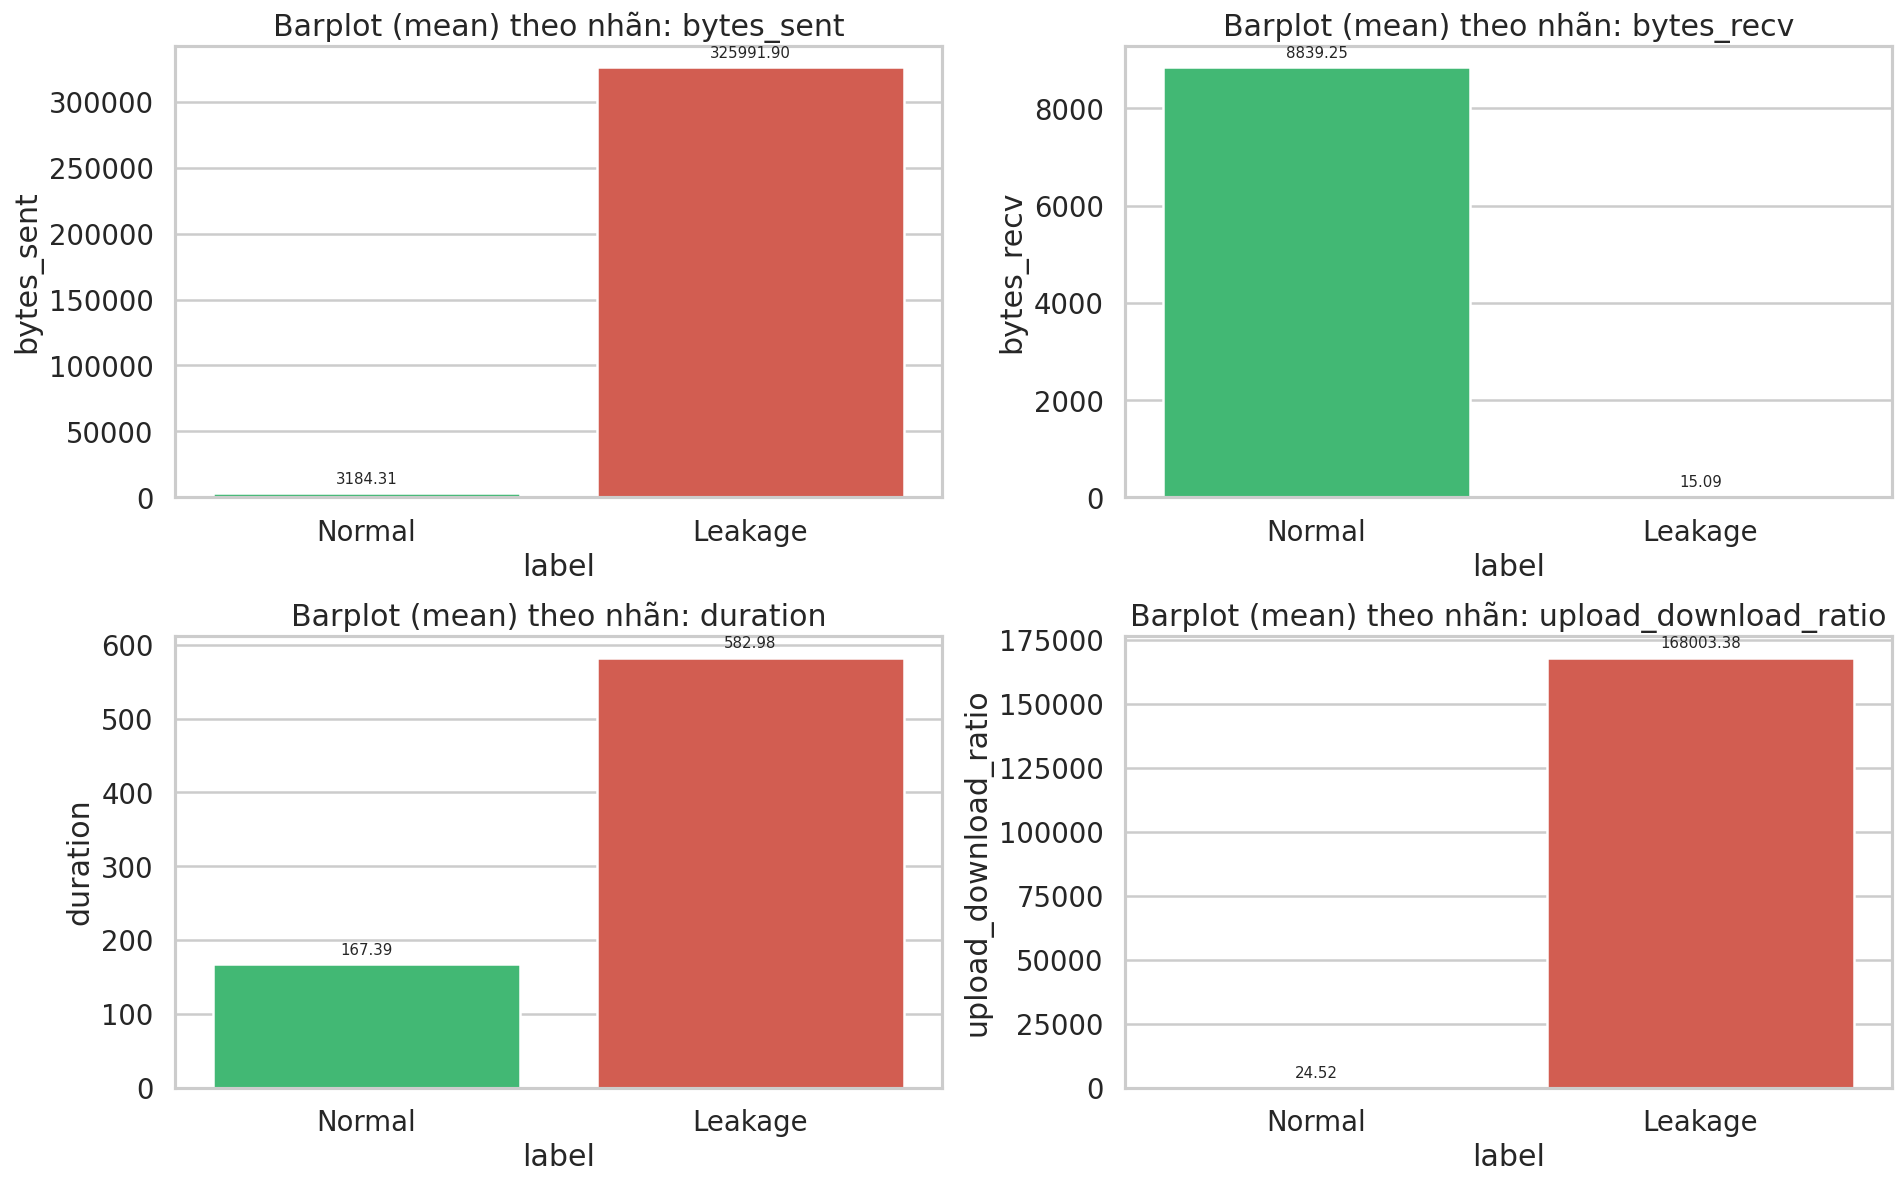

In [5]:
plot_df = df.copy()
plot_df['log_bytes_sent'] = np.log1p(plot_df['bytes_sent'])
plot_df['log_bytes_recv'] = np.log1p(plot_df['bytes_recv'])
plot_df['log_duration'] = np.log1p(plot_df['duration'])
plot_df['log_ratio'] = np.log1p(plot_df['upload_download_ratio'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
numeric_plots = [
    ('log_bytes_sent', 'Phân phối bytes_sent'),
    ('log_bytes_recv', 'Phân phối bytes_recv'),
    ('log_duration', 'Phân phối duration'),
    ('log_ratio', 'Phân phối upload_download_ratio'),
]

for ax, (col, title) in zip(axes.flat, numeric_plots):
    sns.histplot(data=plot_df, x=col, hue='label', kde=True, element='step', stat='density', common_norm=False, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
bar_cols = ['bytes_sent', 'bytes_recv', 'duration', 'upload_download_ratio']
for ax, col in zip(axes.flat, bar_cols):
    sns.barplot(
        data=df,
        x='label',
        y=col,
        hue='label',
        palette=['#2ecc71', '#e74c3c'],
        ax=ax,
        errorbar=None,
        legend=False,
    )
    ax.set_title(f'Barplot (mean) theo nhãn: {col}')
    ax.set_xlabel('label')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Normal', 'Leakage'])

    for patch in ax.patches:
        height = patch.get_height()
        if np.isnan(height):
            continue
        ax.annotate(
            f"{height:.2f}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=9,
            xytext=(0, 4),
            textcoords='offset points',
        )

plt.tight_layout()
plt.show()

## 6. Tương quan giữa các biến và góc nhìn hành vi theo thời gian

Phần này giúp phát hiện mối liên hệ giữa lượng dữ liệu gửi đi, giờ trong ngày và trạng thái kết nối ra ngoài.

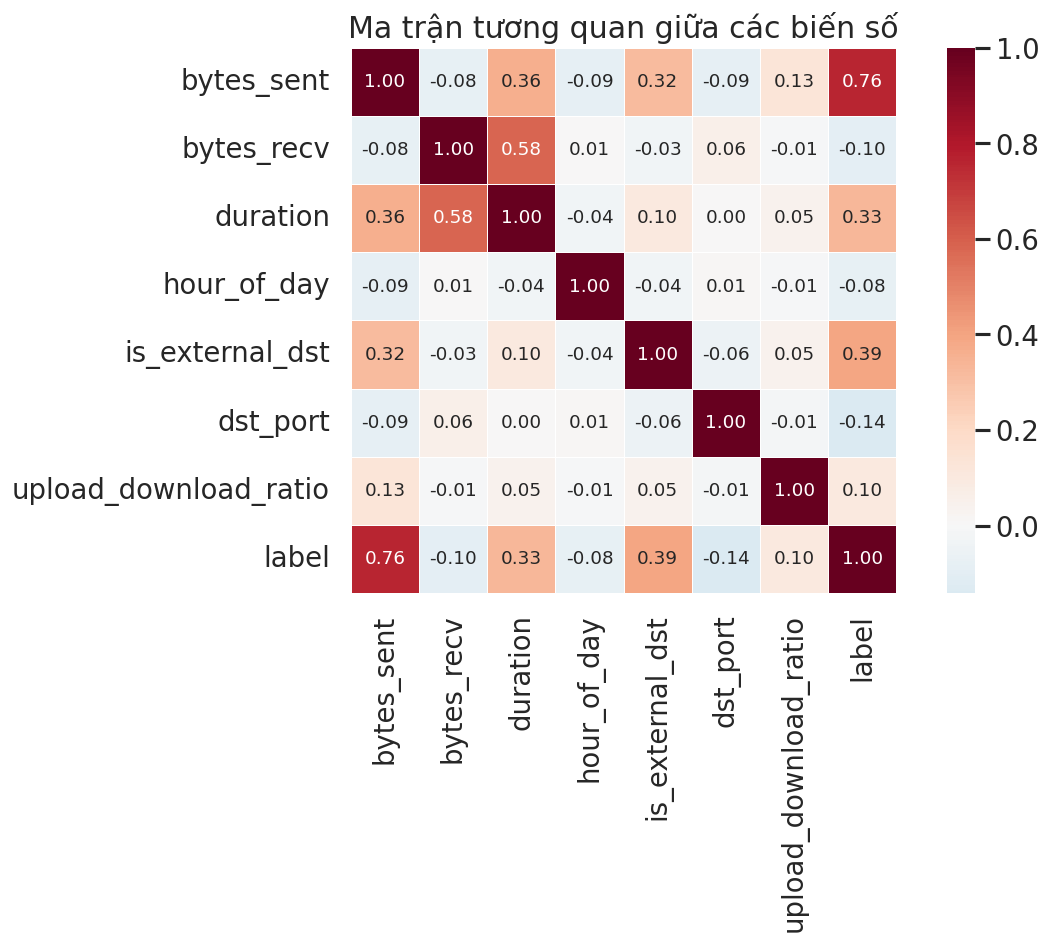

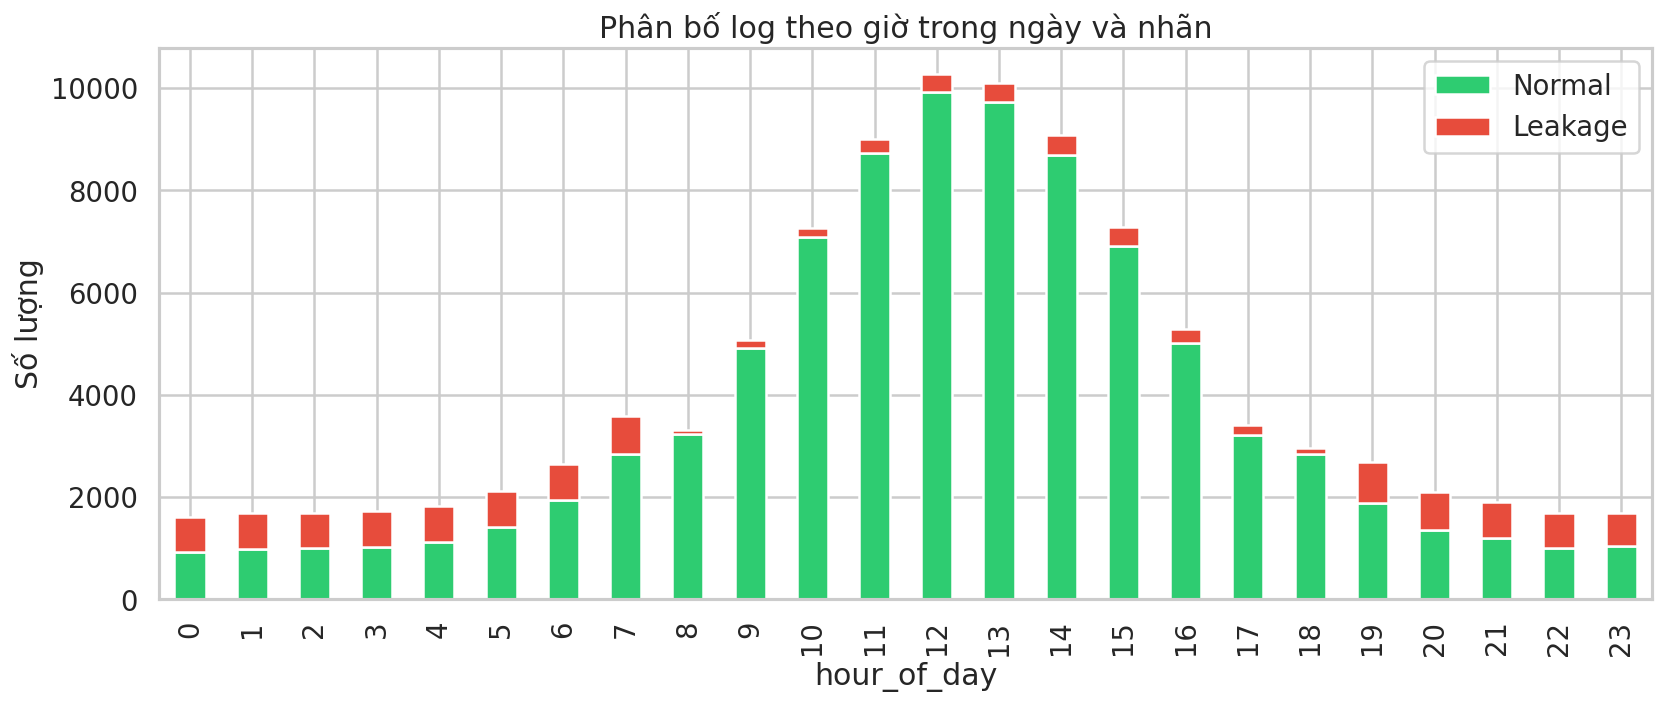

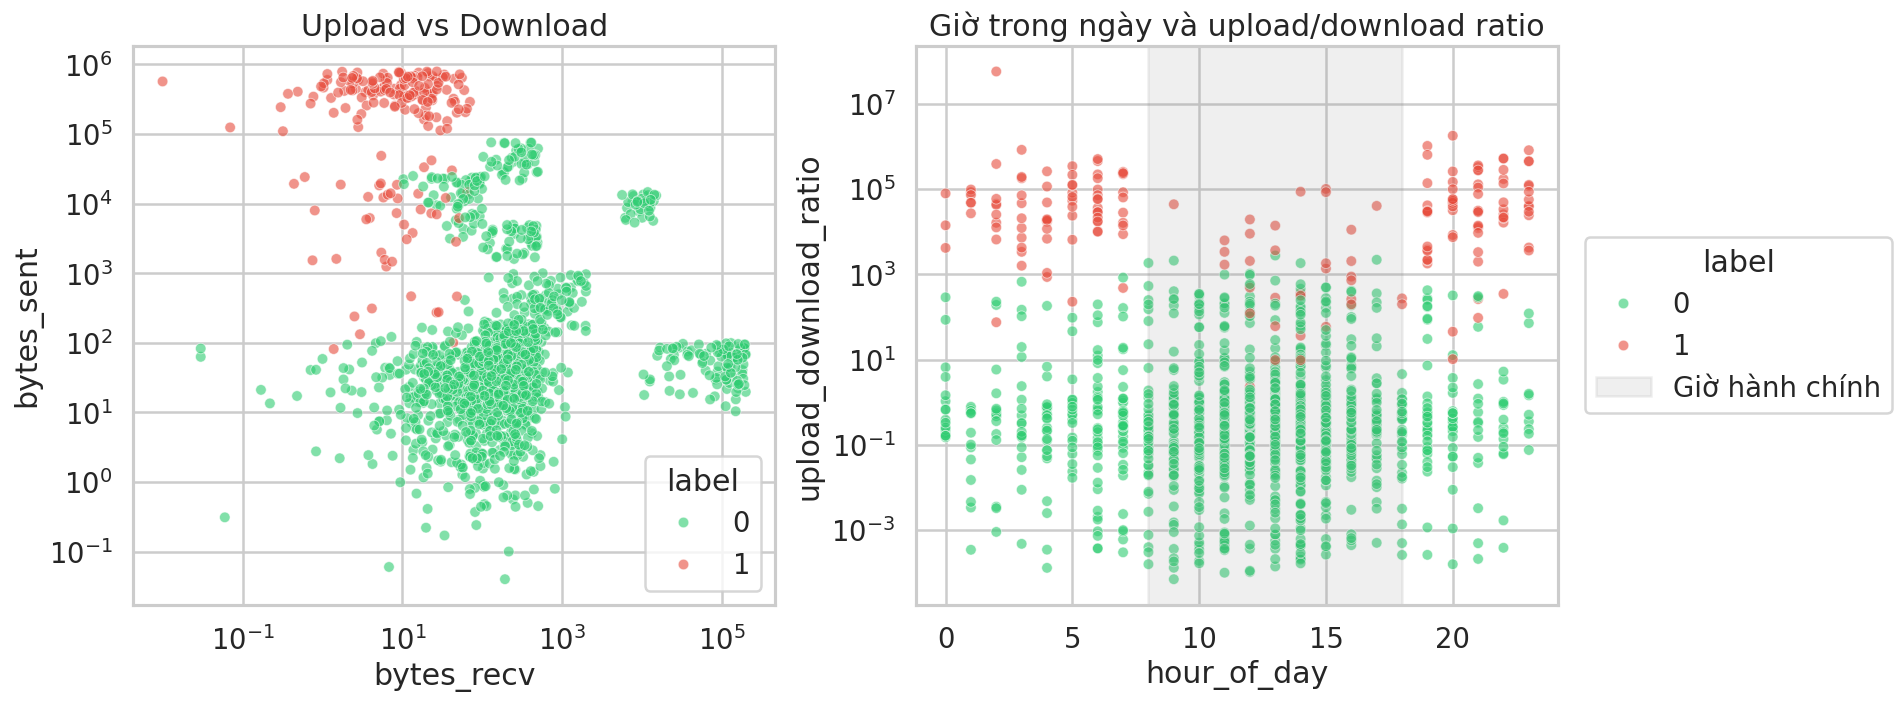

In [6]:
corr_cols = ['bytes_sent', 'bytes_recv', 'duration', 'hour_of_day', 'is_external_dst', 'dst_port', 'upload_download_ratio', 'label']
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.show()

hour_label = df.groupby(['hour_of_day', 'label']).size().unstack(fill_value=0)
ax = hour_label.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(14, 6))
ax.set_title('Phân bố log theo giờ trong ngày và nhãn')
ax.set_xlabel('hour_of_day')
ax.set_ylabel('Số lượng')
ax.legend(['Normal', 'Leakage'])
plt.tight_layout()
plt.show()

sample_size = min(len(df), 1500)
sample_df = df.sample(sample_size, random_state=42)
palette = {0: '#2ecc71', 1: '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=sample_df, x='bytes_recv', y='bytes_sent', hue='label', palette=palette, alpha=0.6, ax=axes[0], s=40)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Upload vs Download')
axes[0].set_xlabel('bytes_recv')
axes[0].set_ylabel('bytes_sent')

sns.scatterplot(data=sample_df, x='hour_of_day', y='upload_download_ratio', hue='label', palette=palette, alpha=0.6, ax=axes[1], s=40)
axes[1].set_yscale('log')
axes[1].axvspan(8, 18, color='gray', alpha=0.12, label='Giờ hành chính')
axes[1].set_title('Giờ trong ngày và upload/download ratio')
axes[1].set_xlabel('hour_of_day')
axes[1].set_ylabel('upload_download_ratio')
axes[1].legend(title='label', loc='center left', bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()

## 6.5. Gợi ý lựa chọn mô hình theo bài toán

Dựa trên đặc thù dữ liệu và các quan sát EDA ở trên, có thể lý giải việc chọn mô hình như sau:

- **Tính phi tuyến và tương tác đặc trưng:** Các điểm rò rỉ thường xuất hiện khi *kết hợp* nhiều điều kiện (ví dụ: upload lớn + ngoài giờ + đích ngoài). Điều này gợi ý mô hình phi tuyến như **Random Forest** sẽ phù hợp hơn mô hình tuyến tính.
- **Mất cân bằng lớp:** Leakage là lớp thiểu số, nên cần mô hình có thể xử lý imbalance tốt (ví dụ `class_weight='balanced'`) và tối ưu theo Recall.
- **Khả năng giải thích:** Trong bài toán bảo mật, cần biết *vì sao* bị cảnh báo. Random Forest cung cấp **feature importance**, dễ trình bày và thuyết minh.
- **Phát hiện hành vi mới (zero-day):** EDA cho thấy có các cụm bất thường hiếm gặp. Mô hình **Isolation Forest** giúp phát hiện outlier ngay cả khi chưa có nhãn.

Vì vậy, hướng hợp lý là dùng **Random Forest** làm mô hình chính (supervised) và **Isolation Forest** như lớp phát hiện bổ sung (unsupervised), còn Logistic Regression giữ vai trò baseline để so sánh.

## 7. Kết luận nhanh

Từ phần EDA, có thể rút ra các điểm chính sau:
- Tập dữ liệu có mất cân bằng lớp, trong đó normal chiếm đa số.
- Leakage thường đi kèm bytes_sent lớn hơn, tỷ lệ upload/download cao hơn và xu hướng kết nối ra ngoài rõ hơn.
- Giờ hoạt động và cổng đích là hai dấu hiệu ngữ cảnh rất hữu ích khi phân tích hành vi mạng.
- Biến upload_download_ratio là đặc trưng dẫn xuất quan trọng để phân tách hành vi bình thường và hành vi rò rỉ.

Nếu muốn đi tiếp, có thể nối notebook này sang phần tiền xử lý và huấn luyện mô hình ngay trên cùng tập dữ liệu.